In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
      precision_score,recall_score,f1_score,confusion_matrix,
      accuracy_score,classification_report,ConfusionMatrixDisplay

)
from sklearn.metrics import roc_curve,roc_auc_score

In [ ]:
Mahi = {
    "G1": [0.123, -0.456, 0.678, 0.895, -0.981, 0.851, 0.658, 0.891, -0.468, 0.568],

    "G2": [0.689, -0.878, -0.967, 0.567, 0.569, -0.898, 0.094, -0.819, 0.900, -0.121],

    "G3": [0.156, -0.685, 0.125, 0.258, -0.385, 0.686, 0.111, -0.888, 0.456, -0.484],

    "G4": [0.998, -0.115, 0.589, -0.155, 0.656, -0.569, 0.478, 0.198, -0.899, 0.858],

    "G5": [0.289, -0.256, -0.358, 0.489, 0.589, 0.680, -0.789, 0.123, 0.586, -0.898],

    "G6": [0.1267, -0.567, 0.898, -0.989, -0.127, 0.656, 0.123, -0.678, 0.585, 0.679],

    "G7": [0,1,0,0,1,0,1,0,1,0]
}

import pandas as pd

df = pd.DataFrame(Mahi)

df

,G1,G2,G3,G4,G5,G6,G7
0,0.123,0.689,0.156,0.998,0.289,0.1267,0
1,-0.456,-0.878,-0.685,-0.115,-0.256,-0.5670,1
2,0.678,-0.967,0.125,0.589,-0.358,0.8980,0
3,0.895,0.567,0.258,-0.155,0.489,-0.9890,0
4,-0.981,0.569,-0.385,0.656,0.589,-0.1270,1
5,0.851,-0.898,0.686,-0.569,0.680,0.6560,0
6,0.658,0.094,0.111,0.478,-0.789,0.1230,1
7,0.891,-0.819,-0.888,0.198,0.123,-0.6780,0
8,-0.468,0.900,0.456,-0.899,0.586,0.5850,1
9,0.568,-0.121,-0.484,0.858,-0.898,0.6790,0


In [ ]:
df.shape


(10, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G1      10 non-null     float64
 1   G2      10 non-null     float64
 2   G3      10 non-null     float64
 3   G4      10 non-null     float64
 4   G5      10 non-null     float64
 5   G6      10 non-null     float64
 6   G7      10 non-null     int64  
dtypes: float64(6), int64(1)
memory usage: 692.0 bytes


In [ ]:
df['G7'].value_counts()

,count
G7,
0,6
1,4


In [ ]:
fraud_count=df['G7'].sum()
legitate_count=len(df)-fraud_count
print(fraud_count)
print(legitate_count)


4
6


In [ ]:
x=df.drop('G7',axis=1)
y=df['G7']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print(f"Train set: {x_train.shape[0]:,} samples")
print(f"Test set:  {x_test.shape[0]:,} samples")

Train set: 8 samples
Test set:  2 samples


In [ ]:

scalar=StandardScaler()
X_scaled_train=scalar.fit_transform(x_train)
X_scaled_test=scalar.transform(x_test)

In [ ]:
model=LogisticRegression()
model.fit(X_scaled_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(X_scaled_test)
y_prob=model.predict_proba(X_scaled_test)[:,1]
y_pred
y_prob

array([0.21559612, 0.50460079])

In [ ]:
y_pred

array([0, 1])

In [ ]:
y_prob

array([0.21559612, 0.50460079])

In [ ]:
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_test,y_pred)
reaca=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {pre:.2f}")
print(f"Recall: {reaca:.2f}")
print(f"F1-score: {f1:.2f}")

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00


In [ ]:
confusion=confusion_matrix(y_test,y_pred)
print(confusion)

[[1 0]
 [0 1]]


In [ ]:
tn,tf,tp,fp=confusion.ravel()
print(tn,tf,tp,fp)

1 0 0 1


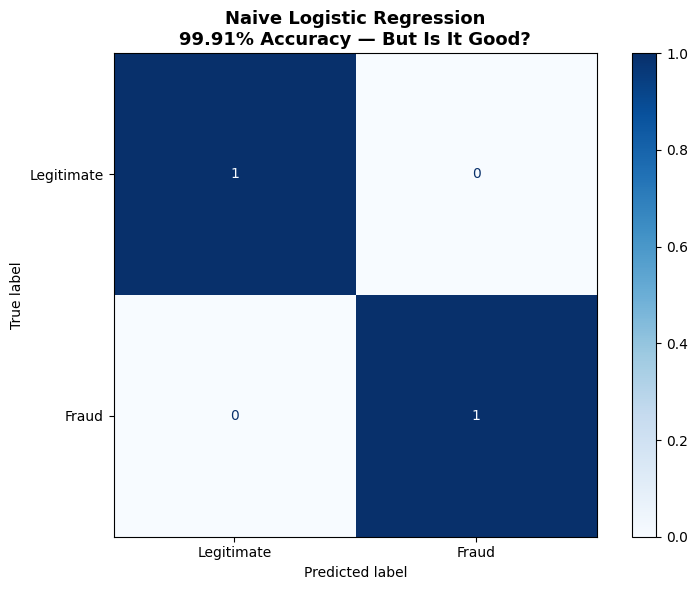

In [ ]:
fig , ax =plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred,
    display_labels=['Legitimate','Fraud'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Naive Logistic Regression\n99.91% Accuracy — But Is It Good?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n full classification report:")
print(classification_report(y_test,y_pred,target_names=['Legitimate','Fraud']))


 full classification report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         1
       Fraud       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
Mahi = {
    "G1": [0.123, -0.456, 0.678, 0.895, -0.981, 0.851, 0.658, 0.891, -0.468, 0.568],

    "G2": [0.689, -0.878, -0.967, 0.567, 0.569, -0.898, 0.094, -0.819, 0.900, -0.121],

    "G3": [0.156, -0.685, 0.125, 0.258, -0.385, 0.686, 0.111, -0.888, 0.456, -0.484],

    "G4": [0.998, -0.115, 0.589, -0.155, 0.656, -0.569, 0.478, 0.198, -0.899, 0.858],

    "G5": [0.289, -0.256, -0.358, 0.489, 0.589, 0.680, -0.789, 0.123, 0.586, -0.898],

    "G6": [0.1267, -0.567, 0.898, -0.989, -0.127, 0.656, 0.123, -0.678, 0.585, 0.679],
    "G7":[0,1,0,0,1,0,1,0,1,0]
}

import pandas as pd

df = pd.DataFrame(Mahi)

df

,G1,G2,G3,G4,G5,G6,G7
0,0.123,0.689,0.156,0.998,0.289,0.1267,0
1,-0.456,-0.878,-0.685,-0.115,-0.256,-0.5670,1
2,0.678,-0.967,0.125,0.589,-0.358,0.8980,0
3,0.895,0.567,0.258,-0.155,0.489,-0.9890,0
4,-0.981,0.569,-0.385,0.656,0.589,-0.1270,1
5,0.851,-0.898,0.686,-0.569,0.680,0.6560,0
6,0.658,0.094,0.111,0.478,-0.789,0.1230,1
7,0.891,-0.819,-0.888,0.198,0.123,-0.6780,0
8,-0.468,0.900,0.456,-0.899,0.586,0.5850,1
9,0.568,-0.121,-0.484,0.858,-0.898,0.6790,0


In [ ]:
fpr , tpr , thresholds = roc_curve(y_test,y_prob)
print(f"Number of thresholds computed: {len(thresholds)}")
print()
print("Sample points:")
print(f"{'Threshold':>12} {'TPR (Recall)':>15} {'FPR':>10}")
print("-" * 40)

for i in range(len(thresholds)):
    print(f"{thresholds[i]:>12.4f} {tpr[i]:>15.4f} {fpr[i]:>10.4f}")


Number of thresholds computed: 3

Sample points:
   Threshold    TPR (Recall)        FPR
----------------------------------------
         inf          0.0000     0.0000
      0.5046          1.0000     0.0000
      0.2156          1.0000     1.0000


In [ ]:
len(thresholds)

3

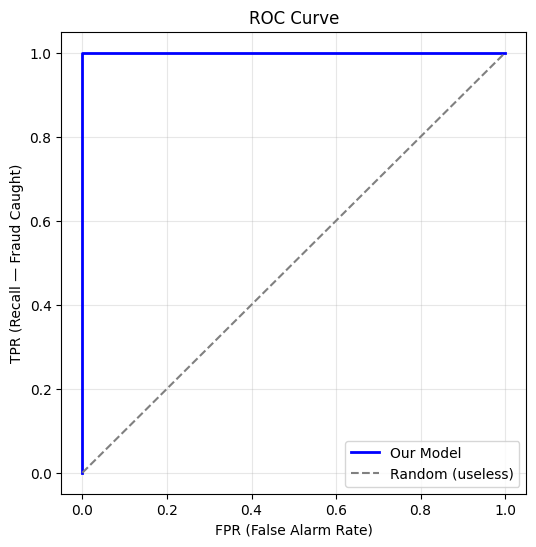

Curve hugs top-left = good model
Curve on diagonal = random (useless)


In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label='Our Model')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Random (useless)')
plt.xlabel('FPR (False Alarm Rate)')
plt.ylabel('TPR (Recall — Fraud Caught)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Curve hugs top-left = good model")
print("Curve on diagonal = random (useless)")

In [ ]:
auc_score=roc_auc_score(y_test,y_prob)
auc_score

np.float64(1.0)

In [ ]:
# Try different thresholds
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FP':>8} {'FN':>5} {'tpr':>5}   {'fpr':5}")
print("-" * 55)

thresholds_to_try = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds_to_try:
    # Convert probabilities to predictions using this threshold
    y_pred = (y_prob>= t).astype(int) # hint

    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr=tp/(tp+fn)
    fpr=fp/(fp+tn)
    print(tpr)
    print(fpr)

    print(f"{t:>10.1f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {fp:>8} {fn:>5} {tpr:>5}  {fpr:>5}")

 Threshold  Precision     Recall         F1       FP    FN   tpr   fpr  
-------------------------------------------------------
1.0
1.0
       0.1     0.5000     1.0000     0.6667        1     0   1.0    1.0
1.0
1.0
       0.2     0.5000     1.0000     0.6667        1     0   1.0    1.0
1.0
0.0
       0.3     1.0000     1.0000     1.0000        0     0   1.0    0.0
1.0
0.0
       0.4     1.0000     1.0000     1.0000        0     0   1.0    0.0
1.0
0.0
       0.5     1.0000     1.0000     1.0000        0     0   1.0    0.0
0.0
0.0
       0.6     0.0000     0.0000     0.0000        0     1   0.0    0.0
0.0
0.0
       0.7     0.0000     0.0000     0.0000        0     1   0.0    0.0
0.0
0.0
       0.8     0.0000     0.0000     0.0000        0     1   0.0    0.0
0.0
0.0
       0.9     0.0000     0.0000     0.0000        0     1   0.0    0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/cardekho_dataset.csv')
df


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [ ]:
df.shape

(15411, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [ ]:
df=df.drop(columns=['Unnamed: 0','car_name','model'])
print(f"shape after dropping:{df.shape}")

shape after dropping:(15411, 11)


In [ ]:
df=pd.get_dummies(df,columns=['brand','seller_type','fuel_type','transmission'], drop_first=True)
print(f"shape after one hot encoding:{df.shape}")

KeyError: "['brand', 'seller_type', 'fuel_type'] not in index"

In [ ]:
X=df.drop(columns=['selling_price'],axis=1)
Y=df['selling_price']
X

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
1,5,20000,18.90,1197,82.00,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
2,11,60000,17.00,1197,80.00,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
3,9,37000,20.92,998,67.10,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
4,6,30000,22.77,1498,98.59,5,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
15407,2,18000,17.50,1373,91.10,7,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
15408,6,67000,21.14,1498,103.52,5,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
15409,5,3800000,16.00,2179,140.00,7,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
Y

,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000
...,...
15406,250000
15407,925000
15408,425000
15409,1225000


In [ ]:
X_train , X_test , Y_train ,Y_test=train_test_split(X,Y,
                                                    test_size=0.2,random_state=42
                                                    )


In [ ]:
X_train

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
11210,7,70252,11.20,2400,215.00,5,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
1347,2,10000,23.84,1199,84.00,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
10363,2,6000,19.00,1950,241.30,5,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
316,7,63000,17.80,1497,117.30,5,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
10638,10,80292,20.36,1197,78.90,5,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,7,127731,20.77,1248,88.80,7,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
13418,11,59000,16.09,1598,103.20,5,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
5390,7,20000,20.51,998,67.04,5,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
860,2,15000,18.60,1197,81.86,5,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True


In [ ]:
numeric_cols=['vehicle_age','km_driven','mileage','engine','max_power','seats']
scalar=StandardScaler()
X_train[numeric_cols]=scalar.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scalar.transform(X_test[numeric_cols])

In [ ]:
model=LinearRegression()
model.fit(X_train,Y_train)


LinearRegression()

In [ ]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)


In [ ]:
y_pred_train

array([3412193.03734086,  538816.57194792, 3107972.27926961, ...,
        315413.96838231,  792625.57941124, 1096655.71792075])

In [ ]:
y_pred_test

array([-57120.8631506 , 656767.14892569, 631434.59648899, ...,
       868994.00589747, 607230.23623819, 950200.93282916])

In [ ]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

train_mae=mean_absolute_error(Y_train,y_pred_train)
train_rmse=np.sqrt(mean_squared_error(Y_train,y_pred_train))
train_r2=r2_score(Y_train,y_pred_train)

test_mae=mean_absolute_error(Y_test,y_pred_test)
test_rmse=np.sqrt(mean_squared_error(Y_test,y_pred_test))
test_r2=r2_score(Y_test,y_pred_test)


print("=" * 55)
print(f"{'Metric':<10} {'Train':>15} {'Test':>15}")
print("=" * 55)
print(f"{'MAE':<10} {'₹{:,.0f}'.format(train_mae):>15} {'₹{:,.0f}'.format(test_mae):>15}")
print(f"{'RMSE':<10} {'₹{:,.0f}'.format(train_rmse):>15} {'₹{:,.0f}'.format(test_rmse):>15}")
print(f"{'R²':<10} {train_r2:>15.4f} {test_r2:>15.4f}")
print("=" * 55)

print(f"\nInterpretation:")
print(f"  • On average, predictions are off by ₹{test_mae:,.0f} on unseen data")
print(f"  • The model explains {test_r2*100:.1f}% of the variance in car prices")

Metric               Train            Test
MAE               ₹199,220        ₹212,488
RMSE              ₹401,160        ₹445,241
R²                  0.8016          0.7367

Interpretation:
  • On average, predictions are off by ₹212,488 on unseen data
  • The model explains 73.7% of the variance in car prices


In [ ]:
coef_df=pd.DataFrame({
    'columns':X_train.columns,
    'coef':model.coef_,

})
coef_df


,columns,coef
0,vehicle_age,-2.276791e+05
1,km_driven,-4.614412e+04
2,mileage,-1.612157e+04
3,engine,7.812630e+04
4,max_power,3.353738e+05
5,seats,3.614477e+04
6,brand_Audi,-1.823317e+06
7,brand_BMW,-1.417458e+06
8,brand_Bentley,1.837978e+06
9,brand_Datsun,-2.533114e+06


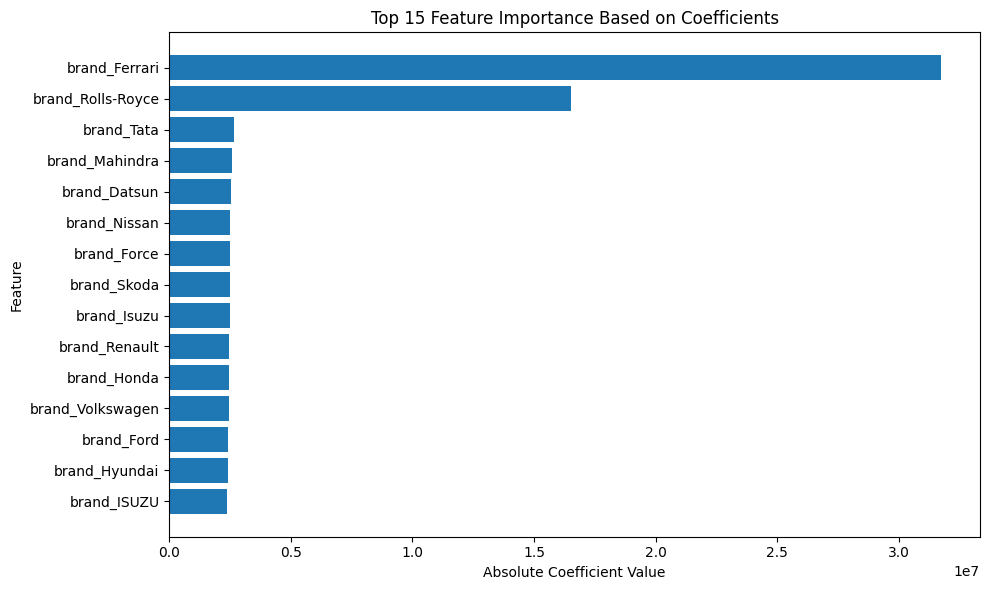

In [ ]:
# Absolute coefficient for importance
coef_df['Abs_Coef'] = coef_df['coef'].abs()

# Top 15 important features
top_features = coef_df.sort_values('Abs_Coef', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features['columns'], top_features['Abs_Coef'])
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance Based on Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
#Display settings
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',120)

In [ ]:
df=pd.read_csv('/content/used_cars_messy (4).csv')
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
df.shape

(15661, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [ ]:
(df.isnull().sum()*100)/len(df)

,0
Unnamed: 0,0.000000
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095


In [ ]:
df.duplicated().sum()


np.int64(169)

In [ ]:
df[df.duplicated(keep=False)].sort_values("car_name")

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4727,1809,Volkswagen Vento,Volkswagen,Vento,7,59000,Dealer,Petrol,Manual,15.04,1598.0,103.60,5.0,450000.0
9546,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
10280,7646,Volkswagen Vento,Volkswagen,Vento,7,32000,Dealer,Diesel,Manual,NaN,1498.0,103.20,5.0,725000.0
911,18223,Volkswagen Vento,Volkswagen,Vento,10,69988,Dealer,Diesel,Manual,20.54,1598.0,103.60,5.0,349000.0


In [ ]:
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [ ]:
colus=["brand","seller_type","transmission_type","fuel_type"]
for c in colus:
  unique=df[c].unique()
  print(unique)


['Renault' 'Maruti' 'Honda' 'Mahindra' 'Hyundai' 'Ford' 'Jeep' 'BMW'
 'Jaguar' 'Skoda' 'Volkswagen' 'Tata' 'Mercedes-Benz' 'Datsun' 'Audi'
 'Tata ' 'Lexus' 'Hyundai ' 'Toyota' 'Maruti ' 'Mahindra ' ' Maruti '
 'BMW ' 'Nissan' ' Mahindra' ' Mahindra ' ' Honda' ' Hyundai' ' Maruti'
 'Land Rover' ' Mercedes-Benz ' 'Mini' ' Honda ' ' Ford ' 'Volvo'
 ' Toyota' 'Porsche' ' Tata ' ' Volkswagen ' ' Hyundai ' 'Kia' 'MG' ' BMW'
 'Isuzu' ' Ford' 'Ford ' ' Renault ' 'Honda ' ' Tata' 'Mercedes-Benz '
 'Toyota ' ' Skoda ' ' Toyota ' ' Renault' 'Skoda ' ' Datsun'
 ' Volkswagen' ' Mercedes-AMG ' 'Audi ' 'Datsun ' ' Porsche' ' Datsun '
 'Volkswagen ' ' Audi' ' Skoda' ' Ferrari ' ' Mini ' 'Bentley' 'Maserati'
 ' Audi ' 'Renault ' ' Nissan ' 'Volvo ' ' BMW ' 'Force' ' Land Rover'
 'ISUZU' ' MG ' ' ISUZU ' 'Rolls-Royce']
['Dealer' 'dealer' 'Individual' 'individual' 'DEALER' 'Trustmark Dealer'
 'Individul' 'Individuall' 'Delaer']
['Manual' 'Automatic']
['Diesel' 'CNG' 'Petrol' 'Petrol ' 'DIESEL' ' Petrol' 

In [ ]:
df['km_driven'].dtype

dtype('O')

In [ ]:
df[df['km_driven']=="67647"]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.8,5.0,575000.0


In [ ]:
df['km_driven'].sample(50).tolist()

['127000',
 '35000',
 '9000',
 '85000',
 '11169',
 '90000',
 '70000',
 '57300',
 '19543',
 '28049',
 '50000',
 '40000',
 '128000',
 '7900',
 '85000',
 '80000',
 '21000',
 '25000',
 '148712',
 '45000',
 '68000',
 '49411',
 '58969',
 '45425',
 '40000',
 '9500',
 '77000',
 '73235',
 '110000',
 '69550',
 '70000',
 '80000',
 '81000',
 '63000',
 '48000',
 '80000',
 '20000',
 '38000',
 '30000',
 '5000',
 '65000',
 '65000',
 '80321',
 '39000',
 '49184',
 '28000',
 '53800',
 '22000',
 '74000',
 '25000']

In [ ]:
df['mileage'].dtype

dtype('O')

In [ ]:
df['mileage'].sample(200).tolist()

['20.4',
 '19.81',
 '22.0',
 '22.74',
 '27.4',
 nan,
 '11.5',
 '20.92',
 '23.26',
 '23.1',
 '22.07',
 '14.94',
 '25.0',
 '25.32',
 '18.9',
 '28.4',
 '27.28',
 '16.02',
 '21.21',
 '20.4',
 '7.5',
 '16.3',
 '17.6',
 '24.0',
 '17.0',
 '16.0',
 '21.21',
 '22.8',
 '16.55',
 '19.7',
 '20.51',
 '23.9',
 '14.74',
 '15.29',
 '12.05',
 '12.05',
 '22.77',
 '28.4',
 '20.54',
 '28.4',
 '17.5',
 '24.3',
 '13.6',
 '20.0',
 '20.51',
 '17.4',
 '21.66',
 '25.2',
 nan,
 '22.74',
 '25.8',
 '20.0',
 '24.7',
 '19.67',
 '18.7',
 '17.3',
 '25.32',
 nan,
 '23.4',
 '33.54',
 '12.99',
 '18.9',
 '23.95',
 '13.5',
 '16.8',
 '20.4',
 '21.9',
 '21.5',
 '20.0',
 '26.59',
 '18.0',
 '15.37',
 '19.7',
 '22.54',
 '23.95',
 '17.5',
 '20.77',
 nan,
 nan,
 '12.99',
 '20.4',
 '21.4',
 '16.36',
 '22.74',
 '17.0',
 '17.0',
 '16.2',
 '15.1',
 '24.04',
 '16.05',
 '25.17',
 '16.0',
 '18.16',
 '20.92',
 nan,
 '20.14',
 '21.4',
 nan,
 '25.17',
 '18.6',
 '22.54',
 nan,
 '20.3',
 '22.54',
 '17.92',
 '19.1',
 '15.85',
 '13.68',
 '20.8

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
df['selling_price'].describe()

,selling_price
count,15503.0000
mean,1032763.7793
std,16073797.4950
min,500.0000
25%,385000.0000
50%,555000.0000
75%,825000.0000
max,999999999.0000


In [ ]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0000,83.8000,5.0000,575000.0000
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0000,67.0400,5.0000,435000.0000
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0000,117.6000,5.0000,875000.0000
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0000,NaN,8.0000,925000.0000
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0000,140.0000,7.0000,1175000.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0000,88.8000,7.0000,665000.0000
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.2000,5.0000,249000.0000
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0000,67.0400,5.0000,250000.0000
15659,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0000,81.8600,5.0000,620000.0000


In [ ]:
df = df.drop(columns=['Unnamed: 0'])


KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type',
       'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

In [ ]:
print(f"unique values:{df['brand'].nunique()}")

unique values:80


In [ ]:
df['brand']=df['brand'].str.strip()
print(f"unique values:{df['brand'].nunique()}")

unique values:32


In [ ]:
print(f"unique values:{df['fuel_type'].nunique()}")
df['fuel_type']=df['fuel_type'].str.strip()
print(f"unique values:{df['fuel_type'].nunique()}")


unique values:5
unique values:5


In [ ]:
df['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer', 'Individul',
       'Individuall', 'Delaer'], dtype=object)

In [ ]:
print(f"unique values:{df['seller_type'].nunique()}")
df['seller_type']=df['seller_type'].str.strip().str.title()
print(f"unique values:{df['seller_type'].nunique()}")
typo_map={
    'Delaer':'Dealer',
    'Individul':'Individual',
    'Individuall':'Individual'
}
df['seller_type']=df['seller_type'].replace(typo_map)

unique values:5
unique values:5


In [ ]:
df['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer'], dtype=object)

In [ ]:
print(f"unique values:{df['transmission_type'].nunique()}")
df['transmission']=df['transmission_type'].str.strip().str.title()
print(f"unique values:{df['transmission_type'].nunique()}")

unique values:2
unique values:2


In [ ]:
df['km_driven']=df['km_driven'].astype(str)
df['km_driven']=df['km_driven'].str.replace(",","")
df['km_driven']=df['km_driven'].str.replace("kms","")
df['km_driven']=df['km_driven'].str.replace("km","")
df['km_driven']=df['km_driven'].str.strip()
df['km_driven']=pd.to_numeric(df['km_driven'],errors='coerce')
df['km_driven'].sample(100)

,km_driven
1459,70000
5502,80000
3255,72000
3546,70000
7709,40000
12210,40000
11685,5000
11198,107000
9070,45000
4652,21900


In [ ]:
df['mileage']=df['mileage'].astype(str).replace("kmpl","")
df['mileage']=df['mileage'].str.strip()
df['mileage']=pd.to_numeric(df['mileage'], errors='coerce')
df['mileage'].sample(100)

,mileage
5256,13.6000
4622,15.2900
7975,17.0000
969,20.9200
3587,25.1700
9390,24.3000
14436,21.5000
1,33.5400
12998,27.2800
11752,20.1400


In [ ]:
df.loc[3,"km_driven"]

np.int64(82000)

In [ ]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1485
engine,1869


In [ ]:
before = len(df)
df=df.dropna(subset=['selling_price'])
after = len(df)
print(before)
print(after)

15661
15503


In [ ]:
for col in ["engine", "mileage", "max_power"]:
  median_val=df[col].median()
  df[col]=df[col].fillna(median_val)

In [ ]:
seats_mode=df['seats'].mode()[0]
df["seats"] = df["seats"].fillna(seats_mode)

In [ ]:
df.duplicated().sum()

np.int64(301)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15202.0000,15202.0000,15202.0000,15202.0000,15202.0000,15202.0000,15202.0000
mean,6.0392,55628.3830,19.6850,1453.1916,99.9758,5.3154,1038807.3195
std,3.0163,51851.6528,3.9691,486.3731,41.9013,0.7974,16231774.8315
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,500.0000
25%,4.0000,30000.0000,17.1000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,555000.0000
75%,8.0000,70000.0000,22.3000,1498.0000,113.4200,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,999999999.0000


Text(0, 0.5, 'Price (₹)')

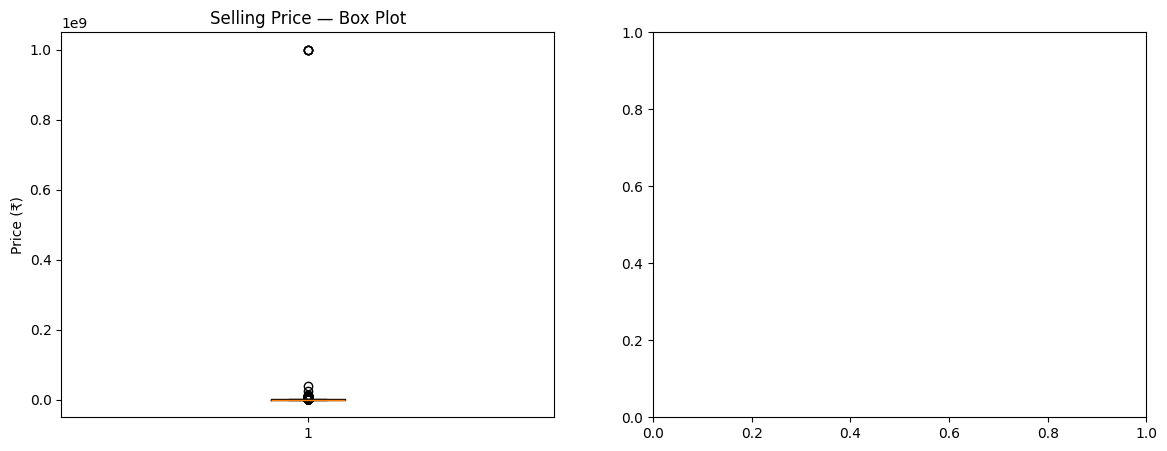

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')

In [ ]:
before = len(df)

df = df[df['selling_price']!=999999999]
df = df[df['selling_price']>10000]
df = df[df['seats']>0]

after = len(df)

print(before,after)

15194 15192


In [ ]:
df['transmission_type'] = df['transmission_type'].map({'Manual':0 ,'Anual':1})
df['transmission_type']

,transmission_type
0,0.0000
1,0.0000
2,0.0000
3,0.0000
4,NaN
...,...
15656,0.0000
15657,0.0000
15658,0.0000
15659,0.0000


# one hot encoding completed


In [ ]:
df['brand'].nunique()

32

In [ ]:
#see the distribution of brands
brand_counts=df['brand'].value_counts()
print(brand_counts)

brand
Maruti           4919
Hyundai          2946
Honda            1464
Mahindra          992
Toyota            790
Ford              772
Volkswagen        610
Renault           522
BMW               434
Tata              424
Mercedes-Benz     331
Skoda             331
Audi              190
Datsun            168
Jaguar             59
Land Rover         50
Jeep               42
Kia                32
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             10
Lexus               9
Isuzu               8
Bentley             3
ISUZU               2
Maserati            2
Ferrari             1
Mercedes-AMG        1
Force               1
Rolls-Royce         1
Name: count, dtype: int64


In [ ]:
rare_brands = brand_counts[brand_counts<100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'ISUZU', 'Maserati', 'Ferrari', 'Mercedes-AMG', 'Force', 'Rolls-Royce']


In [ ]:
df=pd.get_dummies(df,columns=['brand'],drop_first=True)
df

,car_name,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,transmission,seller_type_Automatic,seller_type_Manual,fuel_type_Cng,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_type_0.0,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,Renault Duster,Duster,7,67647,19.8700,1461.0000,83.8000,5.0000,575000.0000,Manual,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,Maruti Wagon R,Wagon R,3,52000,33.5400,998.0000,67.0400,5.0000,435000.0000,Manual,False,True,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,Honda City,City,3,48959,19.6700,1497.0000,117.6000,5.0000,875000.0000,Manual,False,True,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,Mahindra Scorpio,Scorpio,6,82000,15.4000,2179.0000,88.5000,8.0000,925000.0000,Manual,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,Mahindra XUV500,XUV500,4,34000,16.0000,2179.0000,140.0000,7.0000,1175000.0000,Automatic,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Ertiga,7,127731,20.7700,1248.0000,88.8000,7.0000,665000.0000,Manual,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15657,Volkswagen Vento,Vento,11,59000,16.0900,1248.0000,103.2000,5.0000,249000.0000,Manual,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
15658,Maruti Wagon R,Wagon R,7,20000,20.5100,998.0000,67.0400,5.0000,250000.0000,Manual,False,True,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False
15659,Hyundai i20,i20,2,15000,18.6000,1197.0000,81.8600,5.0000,620000.0000,Manual,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
df= df.drop(columns=['car_name','model'],errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler

X = df.drop(columns=['selling_price'])
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
numeric_cols=['vehicle_age','km_driven','mileage','engine','max_power','seats']

In [ ]:
scalar=StandardScaler()


In [ ]:
X_train[numeric_cols]=scalar.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scalar.transform(X_test[numeric_cols])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

print('All imports ready ✅')

All imports ready ✅


In [3]:
# Load
df = pd.read_csv('/content/cardekho_dataset.csv')
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])

# One-hot encode
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

# Separate features and target
X = df.drop(columns=['selling_price'])
y = df['selling_price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} rows')
print('Data prep complete ✅')

Train: 12328 rows, 44 features
Test:  3083 rows
Data prep complete ✅


In [4]:
ols_model=LinearRegression()
ols_model.fit(X_train,y_train)

y_train_pred=ols_model.predict(X_train)
y_test_pred=ols_model.predict(X_test)

ols_train_mae=mean_absolute_error(y_train,y_train_pred)
ols_test_mae=mean_absolute_error(y_test,y_test_pred)

ols_train_r2=r2_score(y_train,y_train_pred)
ols_test_r2=r2_score(y_test,y_test_pred)

print('=' * 55)
print(f'{"OLS Baseline":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(ols_train_mae):>15} {"₹{:,.0f}".format(ols_test_mae):>15}')
print(f'{"R²":<15} {ols_train_r2:>15.4f} {ols_test_r2:>15.4f}')
print('=' * 55)
gap = ols_train_r2 - ols_test_r2
print(f'\nTrain-Test Gap (R²): {gap:.4f}')
print('→ Overfitting detected!' if gap > 0.05 else '→ Gap is small.')

OLS Baseline              Train            Test
MAE                    ₹199,220        ₹212,761
R²                       0.8016          0.7360

Train-Test Gap (R²): 0.0656
→ Overfitting detected!


#ridge model with default alpha


In [6]:
ridge_default=Ridge(alpha=1.0)
ridge_default.fit(X_train,y_train)

ridge_default_train_pred=ridge_default.predict(X_train)
ridge_default_test_pred=ridge_default.predict(X_test)

print('=' * 55)
print(f'{"OLS Baseline":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(ols_train_mae):>15} {"₹{:,.0f}".format(ols_test_mae):>15}')
print(f'{"R²":<15} {ols_train_r2:>15.4f} {ols_test_r2:>15.4f}')
print('=' * 55)
gap = ols_train_r2 - ols_test_r2
print(f'\nTrain-Test Gap (R²): {gap:.4f}')
print('→ Overfitting detected!' if gap > 0.05 else '→ Gap is small.')

OLS Baseline              Train            Test
MAE                    ₹199,220        ₹212,761
R²                       0.8016          0.7360

Train-Test Gap (R²): 0.0656
→ Overfitting detected!


In [7]:
numeric_cols

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Step 1: Scale the numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

# Step 2: Train Ridge model
model = Ridge(alpha=1)
model.fit(X_train_scaled, y_train)

# Step 3: Predict
y_pred = model.predict(X_test_scaled)

In [10]:
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000]

print('Ridge: Cross-Validation Scores Across Alpha Values')
print('=' * 55)
print(f'{"Alpha":>10}  {"CV R² (mean)":>15}  {"CV MAE":>15}')
print('-' * 55)

ridge_results = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', ColumnTransformer([('num', StandardScaler(), numeric_cols)], remainder='passthrough')),
        ('model', Ridge(alpha=alpha))
    ])
    cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_mae = -cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error')

    ridge_results.append({'alpha': alpha, 'cv_r2_mean': cv_r2.mean(), 'cv_mae_mean': cv_mae.mean()})
    print(f'{alpha:>10}  {cv_r2.mean():>15.4f}  {"₹{:,.0f}".format(cv_mae.mean()):>15}')

Ridge: Cross-Validation Scores Across Alpha Values
     Alpha     CV R² (mean)           CV MAE
-------------------------------------------------------
     0.001           0.6812         ₹209,900
      0.01           0.6813         ₹210,009
       0.1           0.6818         ₹211,070
         1           0.6823         ₹217,913
        10           0.6775         ₹230,477
        50           0.6680         ₹239,876
       100           0.6632         ₹243,254
       500           0.6536         ₹246,063
      1000           0.6483         ₹243,577
      5000           0.6088         ₹231,871
     10000           0.5587         ₹236,247


In [12]:
ridge_results

[{'alpha': 0.001,
  'cv_r2_mean': np.float64(0.6811839510155406),
  'cv_mae_mean': np.float64(209899.74697461133)},
 {'alpha': 0.01,
  'cv_r2_mean': np.float64(0.6812508156560501),
  'cv_mae_mean': np.float64(210009.37056330283)},
 {'alpha': 0.1,
  'cv_r2_mean': np.float64(0.6817709279986819),
  'cv_mae_mean': np.float64(211069.99954651884)},
 {'alpha': 1,
  'cv_r2_mean': np.float64(0.6822641506904409),
  'cv_mae_mean': np.float64(217912.69603829816)},
 {'alpha': 10,
  'cv_r2_mean': np.float64(0.6774598587844035),
  'cv_mae_mean': np.float64(230477.15443456368)},
 {'alpha': 50,
  'cv_r2_mean': np.float64(0.667993937245801),
  'cv_mae_mean': np.float64(239876.19835232664)},
 {'alpha': 100,
  'cv_r2_mean': np.float64(0.6631872809981146),
  'cv_mae_mean': np.float64(243253.66683519236)},
 {'alpha': 500,
  'cv_r2_mean': np.float64(0.6535726018464266),
  'cv_mae_mean': np.float64(246063.31393091258)},
 {'alpha': 1000,
  'cv_r2_mean': np.float64(0.6482661688113492),
  'cv_mae_mean': np.float

In [13]:
best_ridge = max(ridge_results, key=lambda x: x['cv_r2_mean'])
print(f'\n✅ Best Ridge alpha: {best_ridge["alpha"]} (CV R² = {best_ridge["cv_r2_mean"]:.4f})')


✅ Best Ridge alpha: 1 (CV R² = 0.6823)


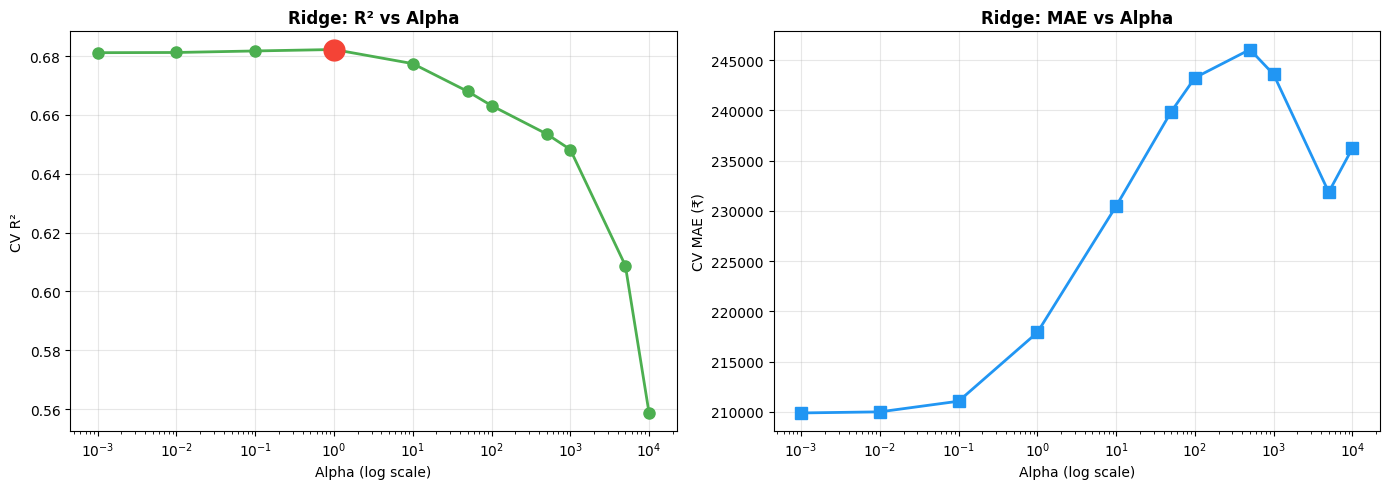

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alphas_plot = [r['alpha'] for r in ridge_results]
r2_means = [r['cv_r2_mean'] for r in ridge_results]
mae_means = [r['cv_mae_mean'] for r in ridge_results]

ax = axes[0]
ax.plot(alphas_plot, r2_means, 'o-', color='#4CAF50', linewidth=2, markersize=8)
best_idx = r2_means.index(max(r2_means))
ax.plot(alphas_plot[best_idx], r2_means[best_idx], 'o', color='#F44336', markersize=15, zorder=6)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV R²')
ax.set_title('Ridge: R² vs Alpha', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(alphas_plot, mae_means, 's-', color='#2196F3', linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV MAE (₹)')
ax.set_title('Ridge: MAE vs Alpha', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
`